In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/dzRf.xlsx')

# Исследование данных

In [3]:
print(f'Количество наблюдений: {df.shape[0]}')
print(f'Количество атрибутов: {df.shape[1]}')

Количество наблюдений: 1952
Количество атрибутов: 21


In [4]:
df.head()

,book_tod,book_dow,book_category,book_staff,last_category,last_staff,last_day_services,last_receipt_tot,last_dow,last_tod,...,last_prod_flag,last_cumrev,last_cumbook,last_cumstyle,last_cumcolor,last_cumprod,last_cumcancel,last_cumnoshow,noshow,recency
0,afternoon,Wednesday,STYLE,JJ,NaN,NaN,0,0.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,morning,Wednesday,COLOR,JOANNE,NaN,NaN,0,0.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,NaN,Wednesday,STYLE,JJ,COLOR,JOANNE,2,262.0,Wednesday,morning,...,1,262,2,1,1,2,0,0,0,35
3,afternoon,Thursday,STYLE,KELLY,NaN,NaN,0,0.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,evening,Saturday,STYLE,KELLY,STYLE,KELLY,1,35.0,Thursday,afternoon,...,0,35,1,1,0,0,0,0,0,9


In [5]:
# статистика по данным
description = df.describe(include='all')
description.to_excel('../data/description.xlsx', index=False)
description


,book_tod,book_dow,book_category,book_staff,last_category,last_staff,last_day_services,last_receipt_tot,last_dow,last_tod,...,last_prod_flag,last_cumrev,last_cumbook,last_cumstyle,last_cumcolor,last_cumprod,last_cumcancel,last_cumnoshow,noshow,recency
count,1717,1952,1952,1952,1003,1003,1952.000000,1952.000000,1003,858,...,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000
unique,3,7,3,7,3,7,NaN,NaN,7,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,afternoon,Thursday,STYLE,JJ,STYLE,JJ,NaN,NaN,Thursday,afternoon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,735,417,1531,722,728,355,NaN,NaN,220,321,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.545082,35.782679,NaN,NaN,...,0.114242,111.258197,1.906762,1.520492,0.325307,0.487193,0.280225,0.422643,0.114754,14.402152
std,NaN,NaN,NaN,NaN,NaN,NaN,0.658514,59.371877,NaN,NaN,...,0.318186,207.927702,3.315854,2.756585,0.827646,1.261275,0.853646,1.319786,0.318807,21.079495
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,60.000000,NaN,NaN,...,0.000000,132.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000


In [17]:
# количество пустых значений
print("Количество пустых значений:")
print(df.isnull().sum())

Количество пустых значений:
book_tod             0
book_dow             0
book_category        0
book_staff           0
last_category        0
last_staff           0
last_day_services    0
last_receipt_tot     0
last_dow             0
last_tod             0
last_noshow          0
last_prod_flag       0
last_cumrev          0
last_cumbook         0
last_cumstyle        0
last_cumcolor        0
last_cumprod         0
last_cumcancel       0
last_cumnoshow       0
noshow               0
recency              0
dtype: int64


Количество категорий в которых есть пропуски 5. К ним относятся book_tod, book_dow, last_category, last_staff, last_dow, last_tod. Категория в которой больше всего пропусков - last_tod

In [7]:
# проведем исследование категорий с пропусками
df.book_tod.value_counts()

book_tod
afternoon    735
morning      548
evening      434
Name: count, dtype: int64

In [8]:
# заполним пропуски в колонке book_tod наиболее часто встречающимся значением
df['book_tod'] = df['book_tod'].fillna('afternoon')

In [18]:
# заполним пропуски в колонках наиболее часто встречающимся значением
df.fillna({
    'last_category': df.last_category.mode()[0],
    'last_staff': df.last_staff.mode()[0],
    'last_dow': df.last_dow.mode()[0],
    'last_tod': df.last_tod.mode()[0]
}, inplace=True)

In [21]:
# разделим датасет на целевой набор и атрибуты
Y = df['noshow']
X = df.drop(columns=['noshow'])

print('Форма атрибутов', X.shape)
print('Форма целевого набора', Y.shape)

Форма атрибутов (1952, 20)
Форма целевого набора (1952,)


In [25]:
# преобразуем категоиальные перемеенные в фиктивные переменные
X = pd.get_dummies(X,drop_first=True)

In [27]:
X.shape

(1952, 44)

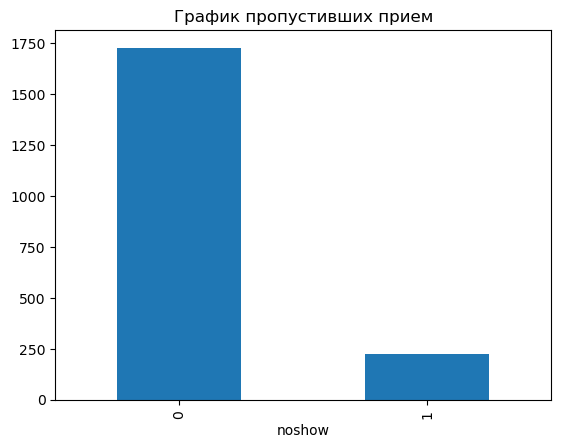

In [23]:
# график не пришедших на прием
Y.value_counts().plot(kind='bar')
plt.title('График пропустивших прием')
plt.show()

количество не пришедших на прием менее 250 (из общего количества 1952 это составляет 13 %)

noshow
0    1728
1     224
Name: count, dtype: int64